<a href="https://colab.research.google.com/github/vansh-virmani/NextGenAI/blob/main/deep_learning0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/My Drive/Deep_learning")

In [2]:
import numpy as np

In [3]:
X=np.array([[1,0,1,0], [1,0,1,1], [0,1,0,1]])
y=np.array([[1],[1],[0]])

In [4]:
def sigmoid_activation(x):
  return 1/(1+np.exp(-x))


In [5]:
def derivative_function(x):
    s = sigmoid_activation(x)
    ds = s * (1 - s)
    return ds

In [6]:
input_neurons=X.shape[1]
hidden_neurons=3
output_neurons=1

wh=np.random.uniform(size=(input_neurons,hidden_neurons))
wout=np.random.uniform(size=(hidden_neurons,output_neurons))
bh= np.random.uniform(size=(1,hidden_neurons))
bout= np.random.uniform(size=(1,output_neurons))



In [7]:
## Z= summation of Xi.Wn +bias
## z'= activationfunction(Z)
## bias+ summation   z'.wout
epochs=1000

In [8]:
## feed forward
for i in range(epochs):
  hidden_layer_input=np.dot(X,wh)+ bh
  hidden_activation= sigmoid_activation(hidden_layer_input)
  output_layer_input=np.dot(hidden_activation,wout)+bout
  output=sigmoid_activation(output_layer_input)
  loss_output=y-output
  slope_output_layer=derivative_function(output)
  delta_output= loss_output * slope_output_layer
  alpha=0.1
  loss_hidden =delta_output.dot(wout.T)
  slope_hidden=derivative_function(hidden_activation)
  delta_hidden=loss_hidden * slope_hidden
  wout= wout+ hidden_activation.T.dot(delta_output)*alpha
  wh=wh+X.T.dot(delta_hidden)*alpha
  bout=bout+np.sum(delta_output,axis=0,keepdims=True)*alpha
  bh=np.sum(delta_hidden,axis=0,keepdims=True)*alpha


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [12]:
(X_train,y_trian),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
X_train.shape  ## images data 60000 images and dim is 28*28

(60000, 28, 28)

In [15]:
x_test.shape

(10000, 28, 28)

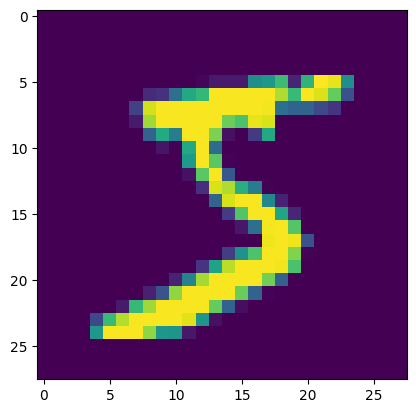

In [17]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

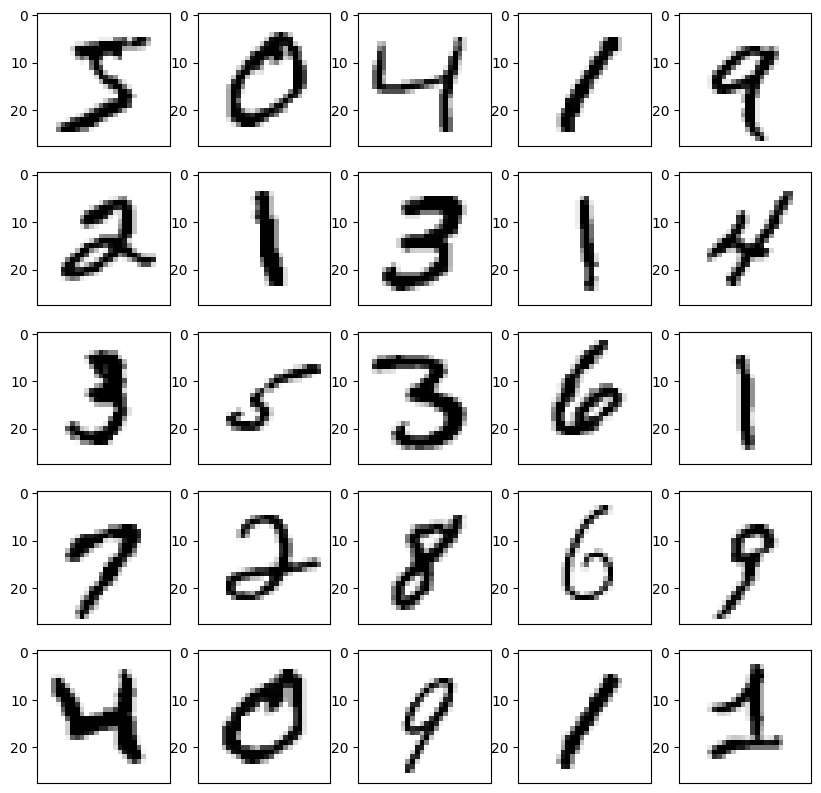

In [19]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.imshow(X_train[i], cmap=plt.cm.binary)
plt.show()

In [20]:
## datapreprocessing
x_train=X_train/255.0
x_test=x_test/255.0

In [21]:
model= Sequential([
    # Input layer- 28*28 input neurons in input layer
    Flatten(input_shape=(28,28)),
    #hidden layer
    Dense(512,activation='sigmoid'),
    Dense(256,activation='sigmoid'),
    Dense(128,activation='sigmoid'),
    #Output layer

    Dense(10,activation='softmax')
    # Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='sgd', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [25]:
model.fit(x_train, y_trian , validation_data=(x_test,y_test), epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.1340 - loss: 2.2921 - val_accuracy: 0.2246 - val_loss: 2.2752
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2368 - loss: 2.2536 - val_accuracy: 0.3964 - val_loss: 2.2218
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.4089 - loss: 2.1309 - val_accuracy: 0.5795 - val_loss: 1.9746
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5406 - loss: 1.7003 - val_accuracy: 0.6437 - val_loss: 1.4094
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.6648 - loss: 1.1880 - val_accuracy: 0.7031 - val_loss: 1.0001


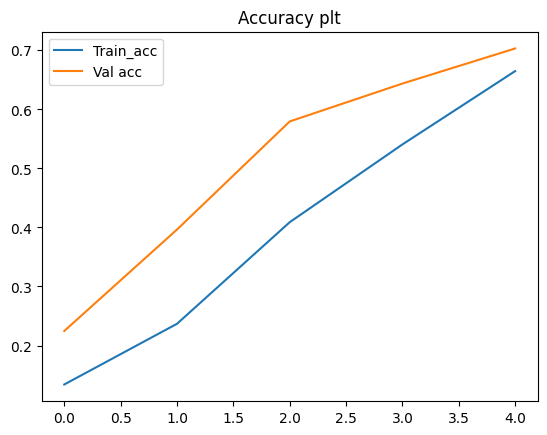

In [26]:
plt.plot(model.history.history['accuracy'],label='Train_acc')
plt.plot(model.history.history['val_accuracy'], label='Val acc')
plt.legend()
plt.title("Accuracy plt")
plt.show()

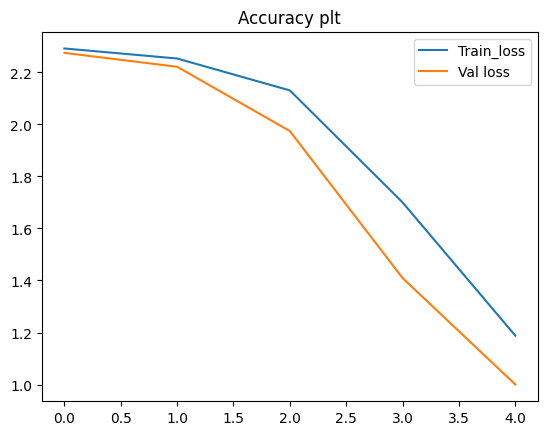

In [27]:
plt.plot(model.history.history['loss'],label='Train_loss')
plt.plot(model.history.history['val_loss'], label='Val loss')
plt.legend()
plt.title("Accuracy plt")
plt.show()